<div dir="rtl" style="text-align:right; line-height:1.8;">
  <h2>01 — تثبيت مكتبات التدريب</h2>

  <p>
    تثبّت هذه الخلية المكتبات الأساسية اللازمة لتدريب نموذج
    <span dir="ltr">SentenceTransformer</span>
    باستخدام بيانات الأزواج، وتشمل مكتبات
    <span dir="ltr">datasets</span>،
    <span dir="ltr">accelerate</span>،
    و
    <span dir="ltr">transformers</span>.
  </p>
</div>

In [ ]:
!pip install -q -U sentence-transformers datasets accelerate transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 205.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 61.4 MB/s eta 0:00:00


<div dir="rtl" style="text-align:right; line-height:1.8;">
  <h2>02 — إعداد البيئة ومسارات التدريب</h2>

  <p>
    تربط هذه الخلية
    <span dir="ltr">Google Drive</span>
    وتستورد مكتبات التدريب، ثم تحدد مسارات أزواج التدريب والتحقق الخاصة بتجربة
    <span dir="ltr">V8</span>.
  </p>

  <p>
    كما تثبّت قيمة
    <span dir="ltr">RANDOM_STATE = 42</span>
    وتتحقق من وجود ملفات الأزواج ومن توفر
    <span dir="ltr">GPU/CUDA</span>
    قبل بدء التدريب.
  </p>
</div>

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import random
import numpy as np
import pandas as pd
import torch

from datasets import Dataset
from sentence_transformers import SentenceTransformer, losses
from sentence_transformers.evaluation import InformationRetrievalEvaluator
from sentence_transformers.trainer import SentenceTransformerTrainer
from sentence_transformers.training_args import SentenceTransformerTrainingArguments, BatchSamplers
from transformers import EarlyStoppingCallback

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

PROJECT_ROOT = Path("/content/drive/MyDrive/semester project/news_comment_topic_system")

PAIR_DIR = PROJECT_ROOT / "training_data/v7_raw_pair_mining_20260428_232654"

TRAIN_PAIRS_PATH = PAIR_DIR / "train_stage1_pairs_v7_raw_large_balanced_1p5M.csv"
VAL_PAIRS_PATH = PAIR_DIR / "val_stage1_pairs_v7_raw_large_balanced_30k.csv"

RUN_NAME = "v8_baseline_minilm_largepairs_epochs10_es3_lr1e5"
OUTPUT_DIR = PROJECT_ROOT / "models" / RUN_NAME
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Train pairs exists:", TRAIN_PAIRS_PATH.exists())
print("Val pairs exists:", VAL_PAIRS_PATH.exists())
print("Output:", OUTPUT_DIR)
print("CUDA:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Mounted at /content/drive


/tmp/ipykernel_871/1074988400.py:11: DeprecationWarning: Importing from 'sentence_transformers.losses' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.losses' instead.
  from sentence_transformers import SentenceTransformer, losses
/tmp/ipykernel_871/1074988400.py:12: DeprecationWarning: Importing from 'sentence_transformers.evaluation' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.evaluation' instead.
  from sentence_transformers.evaluation import InformationRetrievalEvaluator
/tmp/ipykernel_871/1074988400.py:13: DeprecationWarning: Importing from 'sentence_transformers.trainer' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.trainer' instead.
  from sentence_transformers.trainer import SentenceTransformerTrainer
/tmp/ipykernel_871/1074988400.py:14: DeprecationWarning: Importing from 'sentence_transf

Train pairs exists: True
Val pairs exists: True
Output: /content/drive/MyDrive/semester project/news_comment_topic_system/models/v8_baseline_minilm_largepairs_epochs10_es3_lr1e5
CUDA: True
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition


<div dir="rtl" style="text-align:right; line-height:1.8;">
  <h2>03 — تحميل أزواج التدريب والتحقق</h2>

  <p>
    تحمّل هذه الخلية ملفات أزواج
    <span dir="ltr">train</span>
    و
    <span dir="ltr">validation</span>
    مع تثبيت أنواع الأعمدة، ثم تنظف القيم الفارغة وتحول
    <span dir="ltr">similarity</span>
    إلى رقم عشري.
  </p>

  <p>
    تعرض الخلية حجم البيانات وعينة منها وإحصاءات التشابه للتأكد من أن الأزواج جاهزة للتدريب.
  </p>
</div>

In [ ]:
train_pairs = pd.read_csv(
    TRAIN_PAIRS_PATH,
    dtype={"post_id_true": str, "text_a": str, "text_b": str, "split": str},
    low_memory=False
)

val_pairs = pd.read_csv(
    VAL_PAIRS_PATH,
    dtype={"post_id_true": str, "text_a": str, "text_b": str, "split": str},
    low_memory=False
)

train_pairs["similarity"] = train_pairs["similarity"].astype(float)
val_pairs["similarity"] = val_pairs["similarity"].astype(float)

train_pairs = train_pairs.dropna(subset=["text_a", "text_b"]).reset_index(drop=True)
val_pairs = val_pairs.dropna(subset=["text_a", "text_b"]).reset_index(drop=True)

print("Train pairs:", train_pairs.shape)
print("Val pairs:", val_pairs.shape)

display(train_pairs.head())
display(train_pairs["similarity"].describe())
display(val_pairs["similarity"].describe())

Train pairs: (1500000, 5)
Val pairs: (30000, 5)


,post_id_true,text_a,text_b,similarity,split
0,10154675557324067,What a waste of their appearance. Their oath i...,Looks like contempt. Apparently these civil se...,0.627721,train
1,1644964158933163,Don't understand how you can sue someone for b...,"Truthfully, I wouldn't care if Trump blocked m...",0.616384,train
2,10155065604589087,Dumbp the delusional pumpkin-headed buffoon in...,He says crap like that because he's too stupid...,0.661328,train
3,1516953038342031,"Well, i think that most positions held by Demo...",This whole thing hangs on majority and VP... c...,0.605214,train
4,10155608269114060,Hahahaha this guy is savage!!! He says what ev...,Have you ever heard anything more sexist ..it ...,0.469634,train


,similarity
count,1.500000e+06
mean,6.024184e-01
std,6.472059e-02
min,4.500003e-01
25%,5.637642e-01
50%,5.940013e-01
75%,6.389512e-01
max,8.999673e-01


,similarity
count,30000.000000
mean,0.607473
std,0.071215
min,0.450041
25%,0.563961
50%,0.596498
75%,0.646003
max,0.899481


<div dir="rtl" style="text-align:right; line-height:1.8;">
  <h2>04 — تحميل النموذج الأساسي وتفعيل Full Fine-tuning</h2>

  <p>
    تحمّل هذه الخلية النموذج الأساسي
    <span dir="ltr">paraphrase-multilingual-MiniLM-L12-v2</span>
    من البداية، ثم تضبط طول النص على
    <span dir="ltr">256</span>
    وتفعّل تدريب جميع الطبقات.
  </p>

  <p>
    قيمة
    <span dir="ltr">Trainable ratio</span>
    تؤكد أن التدريب هو
    <span dir="ltr">Full Fine-tuning</span>
    وليس تدريب طبقة أخيرة فقط.
  </p>
</div>

In [ ]:
BASE_MODEL_NAME = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
MAX_SEQ_LENGTH = 256

device = "cuda" if torch.cuda.is_available() else "cpu"

model = SentenceTransformer(BASE_MODEL_NAME, device=device)
model.max_seq_length = MAX_SEQ_LENGTH

for param in model.parameters():
    param.requires_grad = True

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Base model:", BASE_MODEL_NAME)
print("Device:", device)
print("Max sequence length:", model.max_seq_length)
print("Trainable ratio:", round(trainable_params / total_params * 100, 2), "%")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Base model: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Device: cuda
Max sequence length: 256
Trainable ratio: 100.0 %


<div dir="rtl" style="text-align:right; line-height:1.8;">
  <h2>05 — تحويل الأزواج إلى Dataset</h2>

  <p>
    تحوّل هذه الخلية أزواج
    <span dir="ltr">text_a</span>
    و
    <span dir="ltr">text_b</span>
    إلى صيغة
    <span dir="ltr">Hugging Face Dataset</span>
    المناسبة للتدريب باستخدام
    <span dir="ltr">SentenceTransformerTrainer</span>.
  </p>

  <p>
    يتم تغيير أسماء الأعمدة إلى
    <span dir="ltr">sentence1</span>
    و
    <span dir="ltr">sentence2</span>
    لأن كل صف يمثل زوجًا موجبًا للتدريب.
  </p>
</div>

In [ ]:
train_dataset = Dataset.from_pandas(
    train_pairs[["text_a", "text_b"]].rename(
        columns={"text_a": "sentence1", "text_b": "sentence2"}
    ),
    preserve_index=False
)

val_dataset = Dataset.from_pandas(
    val_pairs[["text_a", "text_b"]].rename(
        columns={"text_a": "sentence1", "text_b": "sentence2"}
    ),
    preserve_index=False
)

print(train_dataset)
print(val_dataset)

Dataset({
    features: ['sentence1', 'sentence2'],
    num_rows: 1500000
})
Dataset({
    features: ['sentence1', 'sentence2'],
    num_rows: 30000
})


<div dir="rtl" style="text-align:right; line-height:1.8;">
  <h2>06 — إعداد مقيّم الاسترجاع أثناء التدريب</h2>

  <p>
    تنشئ هذه الخلية مقيّم
    <span dir="ltr">InformationRetrievalEvaluator</span>
    باستخدام عينة من
    <span dir="ltr">5000</span>
    زوج من بيانات التحقق.
  </p>

  <p>
    الهدف هو قياس قدرة النموذج على استرجاع
    <span dir="ltr">text_b</span>
    الصحيح عند إعطائه
    <span dir="ltr">text_a</span>
    عبر مقاييس مثل
    <span dir="ltr">Accuracy@10</span>،
    <span dir="ltr">MRR@10</span>،
    و
    <span dir="ltr">MAP@100</span>.
  </p>
</div>

In [ ]:
EVAL_SIZE = 5000

eval_pairs = val_pairs.sample(
    n=min(EVAL_SIZE, len(val_pairs)),
    random_state=RANDOM_STATE
).reset_index(drop=True)

queries = {}
corpus = {}
relevant_docs = {}

for i, row in eval_pairs.iterrows():
    qid = f"q{i}"
    cid = f"c{i}"

    queries[qid] = row["text_a"]
    corpus[cid] = row["text_b"]
    relevant_docs[qid] = {cid}

ir_evaluator = InformationRetrievalEvaluator(
    queries=queries,
    corpus=corpus,
    relevant_docs=relevant_docs,
    name="val_ir_v8",
    show_progress_bar=True,
    accuracy_at_k=[1, 3, 5, 10],
    mrr_at_k=[10],
    ndcg_at_k=[10],
    map_at_k=[100],
)

print("Evaluator size:", len(queries))

Evaluator size: 5000


<div dir="rtl" style="text-align:right; line-height:1.8;">
  <h2>07 — تحديد دالة الخسارة</h2>

  <p>
    تحدد هذه الخلية دالة الخسارة
    <span dir="ltr">MultipleNegativesRankingLoss</span>
    لتدريب النموذج على أزواج
    <span dir="ltr">Comment ↔ Comment</span>
    الموجبة.
  </p>

  <p>
    هذه الدالة تجعل كل زوج صحيح أقرب دلاليًا داخل
    <span dir="ltr">embedding space</span>
    وتستخدم بقية عناصر
    <span dir="ltr">batch</span>
    كأمثلة سالبة ضمنية.
  </p>
</div>

In [ ]:
train_loss = losses.MultipleNegativesRankingLoss(model)

print("Loss:", train_loss)

Loss: MultipleNegativesRankingLoss(
  (model): SentenceTransformer(
    (0): Transformer({'transformer_task': 'feature-extraction', 'modality_config': {'text': {'method': 'forward', 'method_output_name': 'last_hidden_state'}}, 'module_output_name': 'token_embeddings', 'architecture': 'BertModel'})
    (1): Pooling({'embedding_dimension': 384, 'pooling_mode': 'mean', 'include_prompt': True})
  )
)


<div dir="rtl" style="text-align:right; line-height:1.8;">
  <h2>08 — ضبط إعدادات التدريب و Early Stopping</h2>

  <p>
    تضبط هذه الخلية أهم
    <span dir="ltr">hyperparameters</span>
    الخاصة بالتدريب، مثل عدد
    <span dir="ltr">epochs</span>،
    حجم
    <span dir="ltr">batch</span>،
    <span dir="ltr">learning rate</span>،
    وخطوات التقييم والحفظ.
  </p>

  <p>
    تم تفعيل
    <span dir="ltr">load_best_model_at_end</span>
    لاختيار أفضل نسخة حسب
    <span dir="ltr">eval_loss</span>،
    مع استخدام
    <span dir="ltr">NO_DUPLICATES</span>
    لأن التدريب يعتمد على
    <span dir="ltr">MultipleNegativesRankingLoss</span>.
  </p>
</div>

In [ ]:
training_args = SentenceTransformerTrainingArguments(
    output_dir=str(OUTPUT_DIR),

    num_train_epochs=10,

    per_device_train_batch_size=256,
    per_device_eval_batch_size=256,

    learning_rate=1e-5,
    warmup_steps=0.10,
    weight_decay=0.01,

    bf16=True,
    fp16=False,

    batch_sampler=BatchSamplers.NO_DUPLICATES,

    logging_steps=200,

    eval_strategy="steps",
    eval_steps=2000,

    save_strategy="steps",
    save_steps=2000,
    save_total_limit=3,

    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,

    run_name=RUN_NAME,
    seed=RANDOM_STATE,

    dataloader_num_workers=2,

    report_to="none"
)

print(training_args)

SentenceTransformerTrainingArguments(
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
batch_sampler=BatchSamplers.NO_DUPLICATES,
bf16=True,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=2,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=False,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_static_graph=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=False,
enable_jit_checkpoint=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=Fals

<div dir="rtl" style="text-align:right; line-height:1.8;">
  <h2>09 — بناء Trainer مع Early Stopping</h2>

  <p>
    تجمع هذه الخلية النموذج وبيانات التدريب والتحقق ودالة الخسارة والمقيّم داخل
    <span dir="ltr">SentenceTransformerTrainer</span>
    لبدء عملية التدريب بشكل منظم.
  </p>

  <p>
    تم استخدام
    <span dir="ltr">EarlyStoppingCallback</span>
    بقيمة
    <span dir="ltr">patience = 3</span>
    لإيقاف التدريب إذا لم يتحسن
    <span dir="ltr">eval_loss</span>
    خلال ثلاث عمليات تقييم متتالية.
  </p>
</div>

In [ ]:
trainer = SentenceTransformerTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    loss=train_loss,
    evaluator=ir_evaluator,
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=3,
            early_stopping_threshold=0.0
        )
    ]
)

print("Trainer is ready.")

Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Trainer is ready.


<div dir="rtl" style="text-align:right; line-height:1.8;">
  <h2>10 — تشغيل تدريب النموذج</h2>

  <p>
    تبدأ هذه الخلية عملية
    <span dir="ltr">Full Fine-tuning</span>
    للنموذج باستخدام أزواج التعليقات و
    <span dir="ltr">MultipleNegativesRankingLoss</span>.
  </p>

  <p>
    أثناء التدريب يتم تسجيل
    <span dir="ltr">training loss</span>
    وتنفيذ تقييم دوري على بيانات
    <span dir="ltr">validation</span>
    لاختيار أفضل نسخة من النموذج قبل الحفظ النهائي.
  </p>
</div>

In [ ]:
train_result = trainer.train()

print(train_result)

Step,Training Loss,Validation Loss,Val Ir V8 Cosine Accuracy@1,Val Ir V8 Cosine Accuracy@3,Val Ir V8 Cosine Accuracy@5,Val Ir V8 Cosine Accuracy@10,Val Ir V8 Cosine Precision@1,Val Ir V8 Cosine Precision@3,Val Ir V8 Cosine Precision@5,Val Ir V8 Cosine Precision@10,Val Ir V8 Cosine Recall@1,Val Ir V8 Cosine Recall@3,Val Ir V8 Cosine Recall@5,Val Ir V8 Cosine Recall@10,Val Ir V8 Cosine Ndcg@10,Val Ir V8 Cosine Mrr@10,Val Ir V8 Cosine Map@100
2000,1.699643,1.734354,0.154800,0.304600,0.389400,0.514000,0.154800,0.101533,0.077880,0.051400,0.154800,0.304600,0.389400,0.514000,0.316232,0.255147,0.267854
4000,1.630334,1.678588,0.158000,0.312600,0.399000,0.523800,0.158000,0.104200,0.079800,0.052380,0.158000,0.312600,0.399000,0.523800,0.322640,0.260495,0.273466
6000,1.556638,1.656571,0.160400,0.306200,0.401200,0.527000,0.160400,0.102067,0.080240,0.052700,0.160400,0.306200,0.401200,0.527000,0.324310,0.261748,0.274882
8000,1.498540,1.634379,0.160200,0.315000,0.407400,0.525400,0.160200,0.105000,0.081480,0.052540,0.160200,0.315000,0.407400,0.525400,0.325210,0.263181,0.276664
10000,1.463157,1.623569,0.161800,0.317200,0.411000,0.529000,0.161800,0.105733,0.082200,0.052900,0.161800,0.317200,0.411000,0.529000,0.327543,0.265131,0.278471


Batches:   0%|          | 0/157 [00:00<?, ?it/s]

Corpus Chunks:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/157 [00:00<?, ?it/s]

Corpus Chunks: 100%|██████████| 1/1 [00:00<00:00,  1.06it/s]


...

Batches:   0%|          | 0/157 [00:00<?, ?it/s]

Corpus Chunks: 100%|██████████| 1/1 [00:00<00:00,  1.09it/s]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

TrainOutput(global_step=22000, training_loss=1.4666466113003818, metrics={'train_runtime': 5522.5936, 'train_samples_per_second': 2716.115, 'train_steps_per_second': 10.611, 'total_flos': 0.0, 'train_loss': 1.4666466113003818, 'epoch': 3.7542662116040955})


In [ ]:
FINAL_MODEL_DIR = OUTPUT_DIR / "final_model"

model.save_pretrained(str(FINAL_MODEL_DIR))

print("Saved final model:", FINAL_MODEL_DIR)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved final model: /content/drive/MyDrive/semester project/news_comment_topic_system/models/v8_baseline_minilm_largepairs_epochs10_es3_lr1e5/final_model


<div dir="rtl" style="text-align:right; line-height:1.8;">
  <h2>11 — حفظ Metadata التدريب</h2>

  <p>
    تحفظ هذه الخلية ملف
    <span dir="ltr">training_metadata.json</span>
    الذي يوثق إعدادات تجربة التدريب، مثل النموذج الأساسي، عدد الأزواج، عدد
    <span dir="ltr">epochs</span>،
    حجم
    <span dir="ltr">batch</span>،
    معدل التعلم، ونوع
    <span dir="ltr">loss</span>.
  </p>

  <p>
    هذا الملف مهم لتوثيق التجربة وإعادة مراجعتها لاحقًا، خصوصًا أن هذه النسخة تبدأ من
    <span dir="ltr">baseline</span>
    وتستخدم
    <span dir="ltr">early stopping</span>.
  </p>
</div>

In [ ]:
import json

metadata = {
    "experiment_name": RUN_NAME,
    "base_model": BASE_MODEL_NAME,
    "final_model_dir": str(FINAL_MODEL_DIR),

    "training_type": "full_fine_tuning_from_baseline",
    "loss": "MultipleNegativesRankingLoss",

    "train_pairs": int(len(train_pairs)),
    "val_pairs": int(len(val_pairs)),
    "eval_pairs": int(len(eval_pairs)),

    "epochs_max": 10,
    "early_stopping_patience": 3,
    "batch_size": 256,
    "learning_rate": 1e-5,
    "warmup_steps_ratio": 0.10,
    "weight_decay": 0.01,
    "max_seq_length": MAX_SEQ_LENGTH,
    "bf16": True,
    "fp16": False,
    "seed": RANDOM_STATE,

    "total_params": int(total_params),
    "trainable_params": int(trainable_params),
    "trainable_ratio_percent": round(trainable_params / total_params * 100, 2),
}

METADATA_PATH = OUTPUT_DIR / "training_metadata.json"

with open(METADATA_PATH, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print("Saved metadata:", METADATA_PATH)

Saved metadata: /content/drive/MyDrive/semester project/news_comment_topic_system/models/v8_baseline_minilm_largepairs_epochs10_es3_lr1e5/training_metadata.json


<div dir="rtl" style="text-align:right; line-height:1.8;">
  <h2>12 — فحص جودة النموذج بعد التدريب</h2>

  <p>
    تفحص هذه الخلية النموذج بعد التدريب بمقارنة تشابه الأزواج الصحيحة
    <span dir="ltr">positive pairs</span>
    مع أزواج عشوائية.
  </p>

  <p>
    إذا كان النموذج جيدًا، يجب أن يكون متوسط
    <span dir="ltr">cosine similarity</span>
    للأزواج الصحيحة أعلى بوضوح من الأزواج العشوائية، وأن تكون قيمة
    <span dir="ltr">Positive-Random Mean Gap</span>
    كبيرة.
  </p>
</div>

In [ ]:
from sentence_transformers import util

trained_model = SentenceTransformer(str(FINAL_MODEL_DIR), device=device)
trained_model.max_seq_length = MAX_SEQ_LENGTH

sample_pairs = val_pairs.sample(n=1000, random_state=RANDOM_STATE).reset_index(drop=True)

emb_a = trained_model.encode(
    sample_pairs["text_a"].tolist(),
    batch_size=256,
    convert_to_tensor=True,
    normalize_embeddings=True,
    show_progress_bar=True
)

emb_b = trained_model.encode(
    sample_pairs["text_b"].tolist(),
    batch_size=256,
    convert_to_tensor=True,
    normalize_embeddings=True,
    show_progress_bar=True
)

positive_scores = util.cos_sim(emb_a, emb_b).diagonal().detach().cpu().numpy()

random_b = sample_pairs["text_b"].sample(
    frac=1.0,
    random_state=RANDOM_STATE
).tolist()

emb_random_b = trained_model.encode(
    random_b,
    batch_size=256,
    convert_to_tensor=True,
    normalize_embeddings=True,
    show_progress_bar=True
)

random_scores = util.cos_sim(emb_a, emb_random_b).diagonal().detach().cpu().numpy()

print("Average positive-pair cosine:", round(float(np.mean(positive_scores)), 4))
print("Average random-pair cosine:", round(float(np.mean(random_scores)), 4))
print("Positive-Random Mean Gap:", round(float(np.mean(positive_scores) - np.mean(random_scores)), 4))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Average positive-pair cosine: 0.5523
Average random-pair cosine: 0.0479
Positive-Random Mean Gap: 0.5044


<div dir="rtl" style="text-align:right; line-height:1.8;">
  <h2>13 — تحميل بيانات الاختبار النهائية</h2>

  <p>
    تحمّل هذه الخلية مجموعة الاختبار النهائية
    <span dir="ltr">test_large_clean_pool</span>
    وتجهّز نصوص التعليقات في عمود
    <span dir="ltr">model_text</span>
    بنفس أسلوب التنظيف المستخدم في التقييم.
  </p>

  <p>
    هذه البيانات لا تُستخدم في التدريب، بل تُستخدم فقط لاختبار النموذج داخل
    <span dir="ltr">BERTopic</span>
    ومقارنته بالنموذج النهائي المعتمد.
  </p>
</div>

In [ ]:
from pathlib import Path
import re
import numpy as np
import pandas as pd

PROJECT_ROOT = Path("/content/drive/MyDrive/semester project/news_comment_topic_system")

TEST_POOL_PATH = PROJECT_ROOT / "evaluation_data/final_test_pool/test_large_clean_pool.csv"

if not TEST_POOL_PATH.exists():
    TEST_POOL_PATH = PROJECT_ROOT / "training_data/v5_clean_pools_20260420_194922/test_large_clean_pool.csv"

df = pd.read_csv(TEST_POOL_PATH)

print("Test pool:", TEST_POOL_PATH)
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " url ", text)
    text = re.sub(r"\S+@\S+", " email ", text)
    text = re.sub(r"\d+", " number ", text)
    text = re.sub(r"[^a-zA-Z\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

TEXT_COL = "clean_text" if "clean_text" in df.columns else "message"

df["model_text"] = df[TEXT_COL].fillna("").astype(str).apply(clean_text)
df = df[df["model_text"].str.len() > 2].reset_index(drop=True)

docs = df["model_text"].tolist()

print("Final documents:", len(docs))

Test pool: /content/drive/MyDrive/semester project/news_comment_topic_system/evaluation_data/final_test_pool/test_large_clean_pool.csv
Shape: (58014, 27)
Columns: ['date', 'user_id', 'user_name', 'text', 'raw_post_name', 'post_id_true', 'post_text', 'post_description', 'post_link', 'post_page_id', 'post_created_time', 'post_scrape_time', 'post_shares', 'post_react_angry', 'post_react_haha', 'post_react_like', 'post_react_love', 'post_react_sad', 'post_react_wow', 'raw_post_id', 'has_post_context', 'split', 'normalized_text', 'clean_tokens', 'clean_token_count', 'informative_token_count', 'clean_text']
Final documents: 58014


<div dir="rtl" style="text-align:right; line-height:1.8;">
  <h2>14 — توليد Embeddings لبيانات الاختبار</h2>

  <p>
    تستخدم هذه الخلية النموذج المدرّب لتوليد
    <span dir="ltr">embeddings</span>
    لتعليقات مجموعة الاختبار النهائية.
  </p>

  <p>
    هذه التمثيلات الدلالية ستُستخدم لاحقًا داخل
    <span dir="ltr">BERTopic</span>
    لاختبار جودة النموذج في استخراج المواضيع.
  </p>
</div>

In [ ]:
from sentence_transformers import SentenceTransformer

trained_model = SentenceTransformer(str(FINAL_MODEL_DIR), device=device)
trained_model.max_seq_length = 256

embeddings = trained_model.encode(
    docs,
    batch_size=256,
    normalize_embeddings=True,
    show_progress_bar=True
)

embeddings = np.asarray(embeddings)

print("Embeddings shape:", embeddings.shape)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/227 [00:00<?, ?it/s]

Embeddings shape: (58014, 384)


<div dir="rtl" style="text-align:right; line-height:1.8;">
  <h2>15 — تثبيت مكتبات BERTopic</h2>

  <p>
    تثبّت هذه الخلية المكتبات اللازمة لتقييم النموذج داخل
    <span dir="ltr">BERTopic</span>،
    وتشمل
    <span dir="ltr">UMAP</span>
    لاختزال الأبعاد،
    و
    <span dir="ltr">HDBSCAN</span>
    للتجميع،
    و
    <span dir="ltr">NLTK</span>
    لاستخدام
    <span dir="ltr">English stopwords</span>.
  </p>
</div>

In [ ]:
!pip install -q bertopic umap-learn hdbscan nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 6.1 MB/s eta 0:00:00


<div dir="rtl" style="text-align:right; line-height:1.8;">
  <h2>16 — تشغيل BERTopic على Embeddings الاختبار</h2>

  <p>
    تبني هذه الخلية خط
    <span dir="ltr">BERTopic</span>
    باستخدام
    <span dir="ltr">UMAP</span>
    لاختزال الأبعاد،
    و
    <span dir="ltr">HDBSCAN</span>
    لاكتشاف العناقيد،
    و
    <span dir="ltr">CountVectorizer</span>
    لاستخراج كلمات المواضيع.
  </p>

  <p>
    يتم تمرير
    <span dir="ltr">embeddings</span>
    المحسوبة مسبقًا مباشرة إلى
    <span dir="ltr">fit_transform</span>
    لذلك تم ضبط
    <span dir="ltr">embedding_model=None</span>.
  </p>
</div>

In [ ]:
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
import nltk
from nltk.corpus import stopwords

nltk.download("stopwords", quiet=True)

umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

hdbscan_model = HDBSCAN(
    min_cluster_size=100,
    min_samples=10,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)

vectorizer_model = CountVectorizer(
    stop_words=stopwords.words("english"),
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.7
)

topic_model = BERTopic(
    embedding_model=None,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    top_n_words=10,
    calculate_probabilities=True,
    verbose=True
)

topics, probs = topic_model.fit_transform(docs, embeddings)

print("Done.")
print("Documents:", len(docs))
print("Unique topics including -1:", len(set(topics)))
print("Unique valid topics:", len(set(t for t in topics if t != -1)))

2026-05-03 19:48:03,665 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-03 19:48:38,922 - BERTopic - Dimensionality - Completed ✓
2026-05-03 19:48:38,923 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-03 19:48:56,061 - BERTopic - Cluster - Completed ✓
2026-05-03 19:48:56,067 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-03 19:48:57,283 - BERTopic - Representation - Completed ✓


Done.
Documents: 58014
Unique topics including -1: 111
Unique valid topics: 110


<div dir="rtl" style="text-align:right; line-height:1.8;">
  <h2>17 — حساب مقاييس BERTopic النهائية</h2>

  <p>
    تحسب هذه الخلية مقاييس التقييم الأساسية بعد تشغيل
    <span dir="ltr">BERTopic</span>،
    مثل عدد التعليقات الصالحة، عدد تعليقات الضجيج، نسبة الضجيج، عدد المواضيع، متوسط الثقة، و
    <span dir="ltr">Topic Diversity</span>.
  </p>

  <p>
    هذه المقاييس هي الحكم الحقيقي على أداء النموذج داخل
    <span dir="ltr">Topic Modeling</span>،
    وليست مقاييس تصنيف مراقب مثل
    <span dir="ltr">accuracy</span>
    أو
    <span dir="ltr">precision</span>.
  </p>
</div>

In [ ]:
topics_arr = np.array(topics)

total_docs = len(topics_arr)
noise_comments = int((topics_arr == -1).sum())
valid_comments = total_docs - noise_comments

noise_ratio = noise_comments / total_docs * 100
valid_ratio = valid_comments / total_docs * 100
detected_topics = len(set(t for t in topics_arr if t != -1))

if probs is None:
    conf = np.full(total_docs, np.nan)
else:
    probs_arr = np.asarray(probs)
    if probs_arr.ndim == 1:
        conf = probs_arr
    else:
        conf = probs_arr.max(axis=1)

avg_conf_all = float(np.nanmean(conf))
avg_conf_valid = float(np.nanmean(conf[topics_arr != -1]))
median_conf_valid = float(np.nanmedian(conf[topics_arr != -1]))

def topic_diversity(topic_model, top_n=10):
    words = []
    for topic_id in topic_model.get_topics():
        if topic_id == -1:
            continue
        topic_words = topic_model.get_topic(topic_id)
        if topic_words:
            words.extend([w for w, s in topic_words[:top_n]])
    return len(set(words)) / len(words)

diversity = topic_diversity(topic_model, top_n=10)

metrics = {
    "Total Documents": total_docs,
    "Valid Topic Comments": valid_comments,
    "Noise Comments": noise_comments,
    "Valid Ratio": round(valid_ratio, 2),
    "Noise Ratio": round(noise_ratio, 2),
    "Detected Topics": detected_topics,
    "Average Confidence All": round(avg_conf_all * 100, 2),
    "Average Confidence Valid": round(avg_conf_valid * 100, 2),
    "Median Confidence Valid": round(median_conf_valid * 100, 2),
    "Topic Diversity": round(diversity, 4),
}

metrics_df = pd.DataFrame([metrics])
display(metrics_df)

,Total Documents,Valid Topic Comments,Noise Comments,Valid Ratio,Noise Ratio,Detected Topics,Average Confidence All,Average Confidence Valid,Median Confidence Valid,Topic Diversity
0,58014,37504,20510,64.65,35.35,110,33.46,49.72,33.82,0.8755


In [ ]:
BERTOPIC_OUT = OUTPUT_DIR / "bertopic_v8_umap15_mcs100_ms10"
BERTOPIC_OUT.mkdir(parents=True, exist_ok=True)

metrics_path = BERTOPIC_OUT / "metrics_v8_umap15_mcs100_ms10.csv"
topic_info_path = BERTOPIC_OUT / "topic_info_v8_umap15_mcs100_ms10.csv"
assignments_path = BERTOPIC_OUT / "topic_assignments_v8_umap15_mcs100_ms10.csv"
embeddings_path = BERTOPIC_OUT / "embeddings_v8_test_large.npy"
model_path = BERTOPIC_OUT / "bertopic_model_v8"

metrics_df.to_csv(metrics_path, index=False)
topic_model.get_topic_info().to_csv(topic_info_path, index=False)

df["topic"] = topics_arr
df["prob"] = conf
df.to_csv(assignments_path, index=False)

np.save(embeddings_path, embeddings)

topic_model.save(str(model_path), serialization="pickle")

print("Saved metrics:", metrics_path)
print("Saved topic info:", topic_info_path)
print("Saved assignments:", assignments_path)
print("Saved embeddings:", embeddings_path)
print("Saved BERTopic model:", model_path)

Mounted at /content/drive
V7 metrics exists: True
V7 assignments exists: True
V7 topic info exists: True


,Model,Experiment,Total Documents,Valid Topic Comments,Noise Comments,Valid Ratio,Noise Ratio,Detected Topics,Average Confidence All,Average Confidence Valid,...,UMAP n_neighbors,UMAP n_components,UMAP min_dist,UMAP metric,HDBSCAN min_cluster_size,HDBSCAN min_samples,HDBSCAN metric,Vectorizer ngram_range,Vectorizer min_df,Vectorizer max_df
0,V7 FullFT MiniLM RawLargePairs Seq256,v7_seq256_umap15_mcs100_ms10,58014,39458,18556,68.01,31.99,94,56.13,82.52,...,15,5,0.0,cosine,100,10,euclidean,"(1, 2)",2,0.7


V7 assignments shape: (58014, 32)
V7 columns: ['date', 'user_id', 'user_name', 'text', 'raw_post_name', 'post_id_true', 'post_text', 'post_description', 'post_link', 'post_page_id', 'post_created_time', 'post_scrape_time', 'post_shares', 'post_react_angry', 'post_react_haha', 'post_react_like', 'post_react_love', 'post_react_sad', 'post_react_wow', 'raw_post_id', 'has_post_context', 'split', 'normalized_text', 'clean_tokens', 'clean_token_count', 'informative_token_count', 'clean_text', 'text_len', 'word_count', 'model_text', 'topic', 'prob']


<div dir="rtl" style="text-align:right; line-height:1.8;">
  <h2>18 — حفظ نتائج تقييم BERTopic</h2>

  <p>
    تحفظ هذه الخلية مخرجات تقييم
    <span dir="ltr">BERTopic</span>
    الخاصة بتجربة
    <span dir="ltr">V8</span>،
    وتشمل المقاييس، معلومات المواضيع، تعيين كل تعليق إلى موضوعه، والـ
    <span dir="ltr">embeddings</span>
    المستخدمة في الاختبار.
  </p>

  <p>
    كما تحفظ نموذج
    <span dir="ltr">BERTopic</span>
    نفسه بصيغة
    <span dir="ltr">pickle</span>
    حتى يمكن إعادة تحميله لاحقًا دون إعادة تشغيل عملية التجميع من البداية.
  </p>
</div>

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import pandas as pd
import numpy as np

PROJECT_ROOT = Path("/content/drive/MyDrive/semester project/news_comment_topic_system")

V7_DIR = (
    PROJECT_ROOT
    / "bertopic_experiments_clean"
    / "v7_fullft_minilm_raw_largepairs_1p5M_seq256"
    / "v7_seq256_umap15_mcs100_ms10"
)

V7_METRICS_PATH = V7_DIR / "metrics_v7_seq256_umap15_mcs100_ms10.csv"
V7_ASSIGNMENTS_PATH = V7_DIR / "topic_assignments_v7_seq256_umap15_mcs100_ms10.csv"
V7_TOPIC_INFO_PATH = V7_DIR / "topic_info_v7_seq256_umap15_mcs100_ms10.csv"

print("V7 metrics exists:", V7_METRICS_PATH.exists())
print("V7 assignments exists:", V7_ASSIGNMENTS_PATH.exists())
print("V7 topic info exists:", V7_TOPIC_INFO_PATH.exists())

v7_metrics = pd.read_csv(V7_METRICS_PATH)
v7_assignments = pd.read_csv(V7_ASSIGNMENTS_PATH)
v7_topic_info = pd.read_csv(V7_TOPIC_INFO_PATH)

display(v7_metrics)
print("V7 assignments shape:", v7_assignments.shape)
print("V7 columns:", v7_assignments.columns.tolist())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
V7 metrics exists: True
V7 assignments exists: True
V7 topic info exists: True


,Model,Experiment,Total Documents,Valid Topic Comments,Noise Comments,Valid Ratio,Noise Ratio,Detected Topics,Average Confidence All,Average Confidence Valid,...,UMAP n_neighbors,UMAP n_components,UMAP min_dist,UMAP metric,HDBSCAN min_cluster_size,HDBSCAN min_samples,HDBSCAN metric,Vectorizer ngram_range,Vectorizer min_df,Vectorizer max_df
0,V7 FullFT MiniLM RawLargePairs Seq256,v7_seq256_umap15_mcs100_ms10,58014,39458,18556,68.01,31.99,94,56.13,82.52,...,15,5,0.0,cosine,100,10,euclidean,"(1, 2)",2,0.7


V7 assignments shape: (58014, 32)
V7 columns: ['date', 'user_id', 'user_name', 'text', 'raw_post_name', 'post_id_true', 'post_text', 'post_description', 'post_link', 'post_page_id', 'post_created_time', 'post_scrape_time', 'post_shares', 'post_react_angry', 'post_react_haha', 'post_react_like', 'post_react_love', 'post_react_sad', 'post_react_wow', 'raw_post_id', 'has_post_context', 'split', 'normalized_text', 'clean_tokens', 'clean_token_count', 'informative_token_count', 'clean_text', 'text_len', 'word_count', 'model_text', 'topic', 'prob']


<div dir="rtl" style="text-align:right; line-height:1.8;">
  <h2>19 — مقارنة نتائج V8 مع النموذج المعتمد</h2>

  <p>
    تنشئ هذه الخلية جدول مقارنة بين نتائج
    <span dir="ltr">V8</span>
    ونتائج النموذج المعتمد
    <span dir="ltr">V7 Final</span>
    باستخدام مقاييس
    <span dir="ltr">BERTopic</span>
    نفسها.
  </p>

  <p>
    الهدف هو تحديد ما إذا كان التدريب الأطول في
    <span dir="ltr">V8</span>
    حسّن الأداء النهائي أم لا. القرار لا يعتمد على
    <span dir="ltr">training loss</span>
    فقط، بل على نتائج
    <span dir="ltr">Topic Modeling</span>
    مثل
    <span dir="ltr">Noise Ratio</span>
    و
    <span dir="ltr">Valid Topic Comments</span>
    و
    <span dir="ltr">Topic Diversity</span>.
  </p>
</div>

In [ ]:
cols = [
    "Total Documents",
    "Valid Topic Comments",
    "Noise Comments",
    "Valid Ratio",
    "Noise Ratio",
    "Detected Topics",
    "Average Confidence All",
    "Average Confidence Valid",
    "Median Confidence Valid",
    "Topic Diversity"
]

v7_row = v7_metrics.iloc[0].copy()
v8_row = v8_metrics.iloc[0].copy()

v7_row["Model"] = "V7 Final"
v8_row["Model"] = "V8 Baseline Long Training"

comparison = pd.DataFrame([v7_row, v8_row])

available_cols = ["Model"] + [c for c in cols if c in comparison.columns]

display(comparison[available_cols].T)

,0,0
Model,V7 Final,V8 Baseline Long Training
Total Documents,58014.0,58014.0
Valid Topic Comments,39458.0,37504.0
Noise Comments,18556.0,20510.0
Valid Ratio,68.01,64.65
Noise Ratio,31.99,35.35
Detected Topics,94.0,110.0
Average Confidence All,56.13,33.46
Average Confidence Valid,82.52,49.72
Median Confidence Valid,98.08,33.82


<div dir="rtl" style="text-align:right; line-height:1.8;">
  <h2>20 — فحص أفضل Checkpoint في تجربة V8</h2>

  <p>
    تفحص هذه الخلية ملف
    <span dir="ltr">trainer_state.json</span>
    لمعرفة أين توقف التدريب، وما هي أفضل نسخة
    <span dir="ltr">checkpoint</span>
    تم اختيارها حسب
    <span dir="ltr">eval_loss</span>.
  </p>

  <p>
    هذه الخطوة مهمة لأن
    <span dir="ltr">Early Stopping</span>
    قد يوقف التدريب بعد عدة خطوات، بينما تكون أفضل نسخة فعلية عند خطوة سابقة مثل
    <span dir="ltr">checkpoint-16000</span>.
  </p>
</div>

In [ ]:
trainer_state_files = list(V8_MODEL_DIR.rglob("trainer_state.json"))

if trainer_state_files:
    trainer_state_path = sorted(trainer_state_files)[-1]
    print("Using:", trainer_state_path)

    with open(trainer_state_path, "r", encoding="utf-8") as f:
        state = json.load(f)

    print("global_step:", state.get("global_step"))
    print("best_metric:", state.get("best_metric"))
    print("best_model_checkpoint:", state.get("best_model_checkpoint"))

    print("\nLast log entries:")
    for item in state.get("log_history", [])[-10:]:
        print(item)
else:
    print("No trainer_state.json found.")

Using: /content/drive/MyDrive/semester project/news_comment_topic_system/models/v8_baseline_minilm_largepairs_epochs10_es3_lr1e5/checkpoint-22000/trainer_state.json
global_step: 22000
best_metric: 1.615238070487976
best_model_checkpoint: /content/drive/MyDrive/semester project/news_comment_topic_system/models/v8_baseline_minilm_largepairs_epochs10_es3_lr1e5/checkpoint-16000

Last log entries:
{'epoch': 3.4812286689419794, 'grad_norm': 4.664076805114746, 'learning_rate': 7.243268866135761e-06, 'loss': 1.2667362213134765, 'step': 20400}
{'epoch': 3.515358361774744, 'grad_norm': 4.683474540710449, 'learning_rate': 7.205346985210467e-06, 'loss': 1.270921173095703, 'step': 20600}
{'epoch': 3.5494880546075085, 'grad_norm': 4.744788646697998, 'learning_rate': 7.167425104285173e-06, 'loss': 1.2746852111816407, 'step': 20800}
{'epoch': 3.583617747440273, 'grad_norm': 4.901219367980957, 'learning_rate': 7.129503223359879e-06, 'loss': 1.2826393127441407, 'step': 21000}
{'epoch': 3.617747440273037

<div dir="rtl" style="text-align:right; line-height:1.8;">
  <h2>21-Best Checkpoint Inspection</h2>

  <p>
    تفحص هذه الخلية ملف
    <span dir="ltr">trainer_state.json</span>
    الخاص بتجربة
    <span dir="ltr">V8</span>
    لمعرفة آخر خطوة تدريب، أفضل قيمة
    <span dir="ltr">eval_loss</span>،
    وأفضل
    <span dir="ltr">checkpoint</span>
    تم اختياره أثناء التدريب.
  </p>

  <p>
    هذه الخطوة مهمة لتوضيح أن
    <span dir="ltr">Early Stopping</span>
    اختار أفضل نسخة من النموذج بدل الاعتماد على آخر خطوة تدريب فقط.
  </p>
</div>

In [ ]:
import json
from pathlib import Path

PROJECT_ROOT = Path("/content/drive/MyDrive/semester project/news_comment_topic_system")
V8_MODEL_DIR = PROJECT_ROOT / "models/v8_baseline_minilm_largepairs_epochs10_es3_lr1e5"

state_path = V8_MODEL_DIR / "checkpoint-22000" / "trainer_state.json"

with open(state_path, "r", encoding="utf-8") as f:
    state = json.load(f)

print("global_step:", state.get("global_step"))
print("best_metric:", state.get("best_metric"))
print("best_model_checkpoint:", state.get("best_model_checkpoint"))

global_step: 22000
best_metric: 1.615238070487976
best_model_checkpoint: /content/drive/MyDrive/semester project/news_comment_topic_system/models/v8_baseline_minilm_largepairs_epochs10_es3_lr1e5/checkpoint-16000


<div dir="rtl" style="text-align:right; line-height:1.8;">
  <h2>22-Load and Summarize V8 Training Logs</h2>

  <p>
    تحمّل هذه الخلية سجل تدريب
    <span dir="ltr">V8</span>
    من
    <span dir="ltr">trainer_state.json</span>،
    ثم تفصل صفوف التدريب عن صفوف التقييم وتعرض أهم مقاييس
    <span dir="ltr">validation</span>.
  </p>

  <p>
    كما تعرض أفضل
    <span dir="ltr">checkpoint</span>
    الذي اختاره
    <span dir="ltr">Early Stopping</span>
    بناءً على
    <span dir="ltr">eval_loss</span>.
  </p>
</div>

In [12]:
from pathlib import Path
import json
import pandas as pd

V8_MODEL_DIR = Path(
    "/content/drive/MyDrive/semester project/news_comment_topic_system/models/v8_baseline_minilm_largepairs_epochs10_es3_lr1e5"
)

trainer_state_files = list(V8_MODEL_DIR.rglob("trainer_state.json"))

if not trainer_state_files:
    raise FileNotFoundError("No trainer_state.json found")

trainer_state_path = sorted(trainer_state_files)[-1]

with open(trainer_state_path, "r", encoding="utf-8") as f:
    state = json.load(f)

log_df = pd.DataFrame(state["log_history"])

train_log = log_df.dropna(subset=["loss"]).copy()
eval_log = log_df.dropna(subset=["eval_loss"]).copy()

print("Using:", trainer_state_path)
print("Training rows:", train_log.shape[0])
print("Evaluation rows:", eval_log.shape[0])
print("Best checkpoint:", state.get("best_model_checkpoint"))
print("Best eval loss:", state.get("best_metric"))

display(eval_log[[
    "step",
    "eval_loss",
    "eval_val_ir_v8_cosine_accuracy@1",
    "eval_val_ir_v8_cosine_accuracy@10",
    "eval_val_ir_v8_cosine_mrr@10",
    "eval_val_ir_v8_cosine_map@100"
]])

Using: /content/drive/MyDrive/semester project/news_comment_topic_system/models/v8_baseline_minilm_largepairs_epochs10_es3_lr1e5/checkpoint-22000/trainer_state.json
Training rows: 110
Evaluation rows: 11
Best checkpoint: /content/drive/MyDrive/semester project/news_comment_topic_system/models/v8_baseline_minilm_largepairs_epochs10_es3_lr1e5/checkpoint-16000
Best eval loss: 1.615238070487976


,step,eval_loss,eval_val_ir_v8_cosine_accuracy@1,eval_val_ir_v8_cosine_accuracy@10,eval_val_ir_v8_cosine_mrr@10,eval_val_ir_v8_cosine_map@100
10,2000,1.734354,0.1548,0.5140,0.255147,0.267854
21,4000,1.678588,0.1580,0.5238,0.260495,0.273466
32,6000,1.656571,0.1604,0.5270,0.261748,0.274882
43,8000,1.634379,0.1602,0.5254,0.263181,0.276664
54,10000,1.623569,0.1618,0.5290,0.265131,0.278471
65,12000,1.620027,0.1630,0.5298,0.265609,0.279008
76,14000,1.618503,0.1634,0.5342,0.266409,0.279520
87,16000,1.615238,0.1622,0.5330,0.265407,0.278700
98,18000,1.621770,0.1622,0.5352,0.265291,0.278367
109,20000,1.623040,0.1646,0.5324,0.266028,0.279326


<div dir="rtl" style="text-align:right; line-height:1.8;">
  <h2>23-Training and Validation Loss Curve</h2>

  <p>
    ترسم هذه الخلية منحنى
    <span dir="ltr">Training Loss</span>
    و
    <span dir="ltr">Validation Loss</span>
    عبر خطوات التدريب.
  </p>

  <p>
    الهدف هو مراقبة التعلم واكتشاف بداية
    <span dir="ltr">overfitting</span>:
    إذا استمر
    <span dir="ltr">Training Loss</span>
    بالانخفاض بينما بدأ
    <span dir="ltr">Validation Loss</span>
    بالارتفاع، فهذا يعني أن النموذج لم يعد يتحسن على بيانات التحقق.
  </p>
</div>

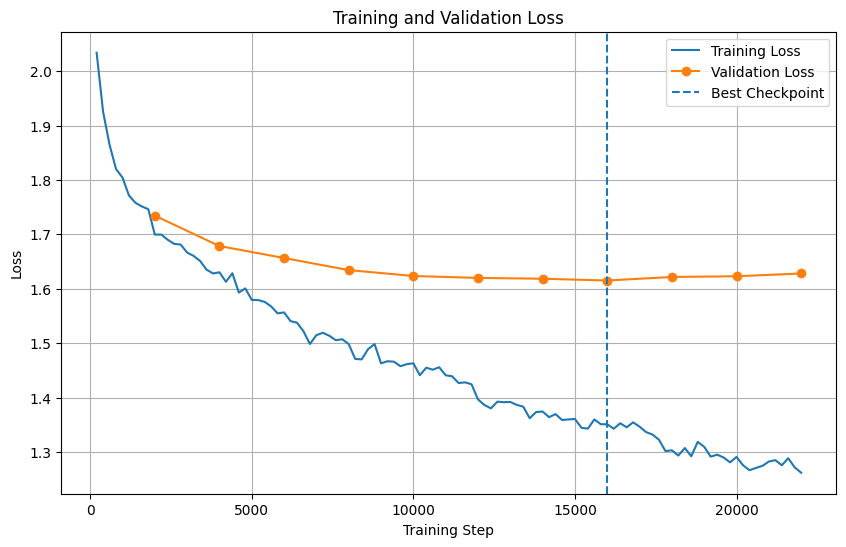

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    train_log["step"],
    train_log["loss"],
    label="Training Loss"
)

plt.plot(
    eval_log["step"],
    eval_log["eval_loss"],
    marker="o",
    label="Validation Loss"
)

plt.axvline(
    16000,
    linestyle="--",
    label="Best Checkpoint"
)

plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.grid(True)
plt.legend()
plt.show()

<div dir="rtl" style="text-align:right; line-height:1.8;">
  <h2>24-Validation Accuracy@K Curve</h2>

  <p>
    ترسم هذه الخلية تطور
    <span dir="ltr">Accuracy@1</span>
    و
    <span dir="ltr">Accuracy@10</span>
    أثناء تقييم النموذج على أزواج التحقق.
  </p>

  <p>
    هذه القيم تقيس قدرة نموذج
    <span dir="ltr">embeddings</span>
    على استرجاع
    <span dir="ltr">text_b</span>
    الصحيح عند إعطائه
    <span dir="ltr">text_a</span>.
    وهي ليست دقة تصنيف نهائية للمشروع.
  </p>
</div>

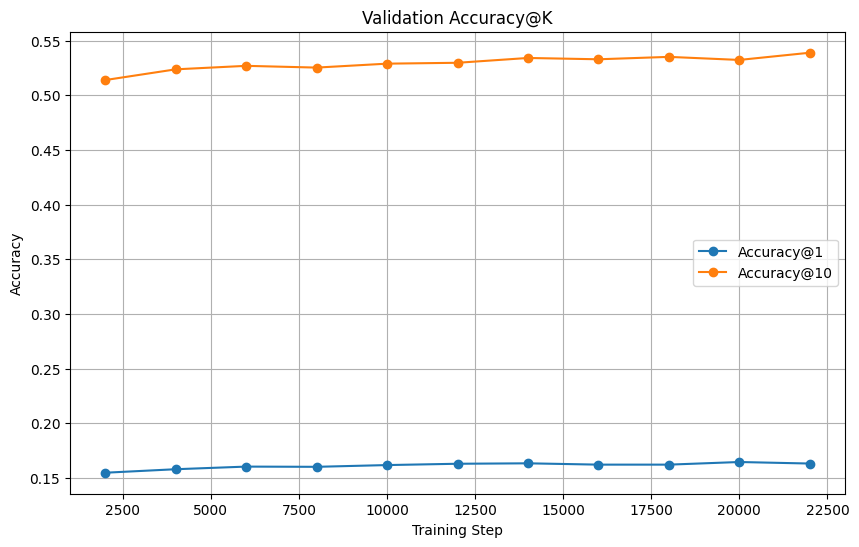

In [4]:
plt.figure(figsize=(10, 6))

plt.plot(
    eval_log["step"],
    eval_log["eval_val_ir_v8_cosine_accuracy@1"],
    marker="o",
    label="Accuracy@1"
)

plt.plot(
    eval_log["step"],
    eval_log["eval_val_ir_v8_cosine_accuracy@10"],
    marker="o",
    label="Accuracy@10"
)

plt.xlabel("Training Step")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy@K")
plt.grid(True)
plt.legend()
plt.show()

<div dir="rtl" style="text-align:right; line-height:1.8;">
  <h2>25-Validation Retrieval Metrics Curve</h2>

  <p>
    ترسم هذه الخلية مقاييس
    <span dir="ltr">MRR@10</span>،
    <span dir="ltr">MAP@100</span>،
    و
    <span dir="ltr">NDCG@10</span>
    أثناء تقييم النموذج على أزواج التحقق.
  </p>

  <p>
    هذه المقاييس تقيس جودة ترتيب النتائج في مهمة الاسترجاع:
    هل يظهر
    <span dir="ltr">text_b</span>
    الصحيح ضمن المراتب الأولى عند البحث باستخدام
    <span dir="ltr">text_a</span>.
    وهي مقاييس لتدريب
    <span dir="ltr">embeddings</span>
    وليست تقييمًا نهائيًا للمواضيع.
  </p>
</div>

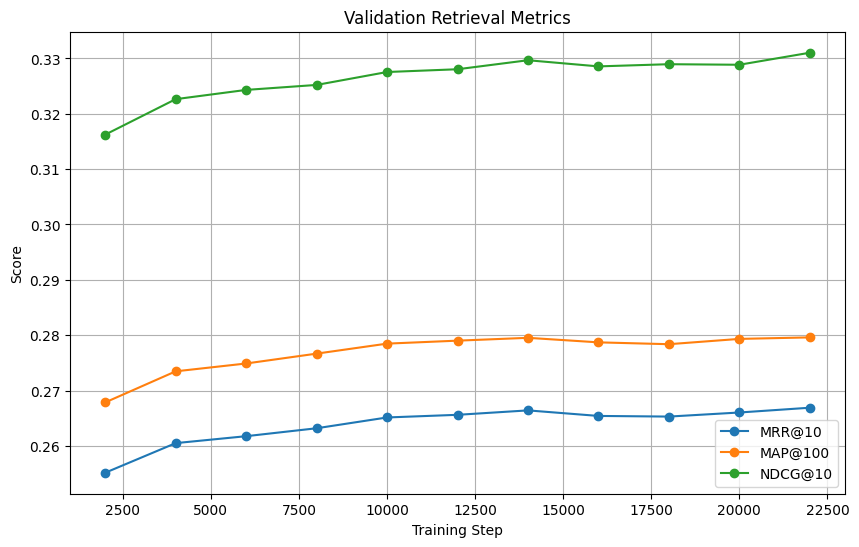

In [5]:
plt.figure(figsize=(10, 6))

plt.plot(
    eval_log["step"],
    eval_log["eval_val_ir_v8_cosine_mrr@10"],
    marker="o",
    label="MRR@10"
)

plt.plot(
    eval_log["step"],
    eval_log["eval_val_ir_v8_cosine_map@100"],
    marker="o",
    label="MAP@100"
)

plt.plot(
    eval_log["step"],
    eval_log["eval_val_ir_v8_cosine_ndcg@10"],
    marker="o",
    label="NDCG@10"
)

plt.xlabel("Training Step")
plt.ylabel("Score")
plt.title("Validation Retrieval Metrics")
plt.grid(True)
plt.legend()
plt.show()

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

comparison_data = pd.DataFrame({
    "Metric": [
        "Valid Topic Comments",
        "Noise Comments",
        "Noise Ratio",
        "Detected Topics",
        "Average Confidence Valid",
        "Topic Diversity"
    ],
    "V7 Final": [
        39458,
        18556,
        31.99,
        94,
        82.52,
        0.9011
    ],
    "V8": [
        37504,
        20510,
        35.35,
        110,
        49.72,
        0.8755
    ]
})

display(comparison_data)

,Metric,V7 Final,V8
0,Valid Topic Comments,39458.0000,37504.0000
1,Noise Comments,18556.0000,20510.0000
2,Noise Ratio,31.9900,35.3500
3,Detected Topics,94.0000,110.0000
4,Average Confidence Valid,82.5200,49.7200
5,Topic Diversity,0.9011,0.8755
